# Lab 04：拆開 attention 與 Transformer 區塊

對應講義：[第 04 課](../lessons/04_attention_and_transformer.md)

1. 手算一次 attention（式 4.1），看 causal mask 的效果
2. 為什麼要除以 $\sqrt{d_k}$（式 4.2）：softmax 飽和
3. 沒有位置資訊時，attention 對排列等變（§2.4）
4. RoPE：分數只和相對距離有關（式 4.5）
5. 零件比較：LayerNorm vs RMSNorm、四種激活函數、MHA vs GQA 的參數量

CPU 不到 1 分鐘。

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)

## 1. 手算 attention

6 個位置、每個 8 維，一個 head。先不加 mask，再加 causal mask。

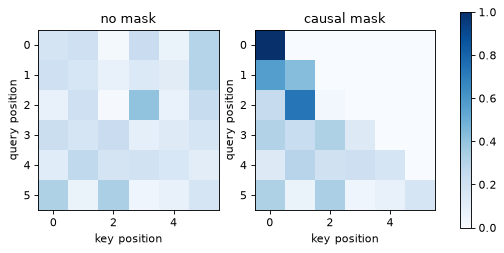

rows sum to 1: True
matches attention_reference: True
position 0 only sees itself -> output equals v[0]: True


In [2]:
from lm_course.model import attention_reference

T, d = 6, 8
x = torch.randn(T, d)
W_q, W_k, W_v = (torch.randn(d, d) / math.sqrt(d) for _ in range(3))
q, k, v = x @ W_q, x @ W_k, x @ W_v

scores = q @ k.T / math.sqrt(d)
weights_full = scores.softmax(dim=-1)
mask = torch.ones(T, T).triu(1).bool()
weights_causal = scores.masked_fill(mask, float("-inf")).softmax(dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, w, title in [(axes[0], weights_full, "no mask"), (axes[1], weights_causal, "causal mask")]:
    im = ax.imshow(w, cmap="Blues", vmin=0, vmax=1)
    ax.set_xlabel("key position")
    ax.set_ylabel("query position")
    ax.set_title(title)
plt.colorbar(im, ax=axes)
plt.show()

out = weights_causal @ v
ref = attention_reference(q[None, None], k[None, None], v[None, None], causal=True)[0, 0]
print("rows sum to 1:", torch.allclose(weights_causal.sum(-1), torch.ones(T)))
print("matches attention_reference:", torch.allclose(out, ref, atol=1e-6))
print("position 0 only sees itself -> output equals v[0]:", torch.allclose(out[0], v[0]))

causal mask 下的權重矩陣是下三角：第 $i$ 列只分配給 $0..i$。第 0 個位置只能看自己，所以輸出就是 $v_0$。

## 2. $\sqrt{d_k}$ 縮放

隨機的 $q$、$k$（分量變異數 1），比較「除以 $\sqrt{d_k}$」與「不除」時：分數的標準差、attention 權重的熵（均勻分布在 64 個位置上的熵是 $\ln 64 \approx 4.16$）、最大權重。

In [3]:
T = 64
print(f"{'d_k':>5} | {'score std':>9} {'entropy':>8} {'max w':>6} | unscaled: {'score std':>9} {'entropy':>8} {'max w':>6}")
for d_k in (4, 16, 64, 256, 1024):
    q, k = torch.randn(200, T, d_k), torch.randn(200, T, d_k)
    raw = q @ k.transpose(-2, -1)
    row = []
    for s in (raw / math.sqrt(d_k), raw):
        w = s.softmax(dim=-1)
        entropy = -(w * w.clamp_min(1e-12).log()).sum(-1).mean()
        row.append((s.std().item(), entropy.item(), w.max(-1).values.mean().item()))
    (a, b, c), (e, f, g) = row
    print(f"{d_k:5d} | {a:9.2f} {b:8.2f} {c:6.2f} | {'':9} {e:9.2f} {f:8.2f} {g:6.2f}")

  d_k | score std  entropy  max w | unscaled: score std  entropy  max w
    4 |      1.00     3.70   0.10 |                2.01     2.81   0.27


   16 |      1.00     3.69   0.11 |                4.00     1.37   0.58
   64 |      1.00     3.69   0.11 |                8.00     0.58   0.79


  256 |      1.00     3.69   0.11 |               16.00     0.27   0.90


 1024 |      1.00     3.69   0.11 |               32.03     0.13   0.95


縮放後，分數的標準差固定在 1 左右，不管維度多大；不縮放時標準差是 $\sqrt{d_k}$，softmax 幾乎變成 one-hot（熵趨近 0、最大權重趨近 1）——這時梯度幾乎為 0，模型很難學。

## 3. 沒有位置資訊時的排列等變性

拿一個 `Attention` 模組，不給 RoPE，**不加 causal mask**（`causal=False`）。把輸入的順序打亂，輸出是否只是跟著打亂？再打開 causal mask 看看。

In [4]:
from lm_course.model import Attention, GPTConfig

perm = torch.randperm(10)
x = torch.randn(1, 10, 32)
for causal in (False, True):
    attn = Attention(GPTConfig(d_model=32, n_head=4, causal=causal)).eval()
    with torch.no_grad():
        y = attn(x, rope=None, layer=0, kv_cache=None)
        y_perm = attn(x[:, perm], rope=None, layer=0, kv_cache=None)
    print(f"causal={causal}: attn(P x) == P attn(x)?  {torch.allclose(y_perm, y[:, perm], atol=1e-6)}")

causal=False: attn(P x) == P attn(x)?  True
causal=True: attn(P x) == P attn(x)?  False


沒有 mask 時，attention 完全不知道順序；有了 causal mask，「看得到幾個位置」本身就洩漏了位置，等變性被打破（講義 §2.4）。但只靠這一點資訊學位置很吃力，所以實務上還是要明確加入位置編碼。

## 4. RoPE

先檢查式 (4.5)：固定一對 $q$、$k$，把它們放在不同的絕對位置，只要相對距離相同，分數就相同。

In [5]:
from lm_course.model import apply_rope, rope_cache

head_dim = 64
cos, sin = rope_cache(2048, head_dim)
q, k = torch.randn(2, head_dim)


def rope_score(m: int, n: int, base_cos: torch.Tensor = cos, base_sin: torch.Tensor = sin) -> float:
    qm = apply_rope(q.view(1, 1, 1, -1), base_cos[m : m + 1], base_sin[m : m + 1])
    kn = apply_rope(k.view(1, 1, 1, -1), base_cos[n : n + 1], base_sin[n : n + 1])
    return (qm * kn).sum().item()


for m, n in [(0, 5), (100, 105), (1000, 1005), (7, 3), (507, 503)]:
    print(f"query at {m:4d}, key at {n:4d} (distance {n - m:+d}): score {rope_score(m, n):+.4f}")

query at    0, key at    5 (distance +5): score -7.8776
query at  100, key at  105 (distance +5): score -7.8776
query at 1000, key at 1005 (distance +5): score -7.8776
query at    7, key at    3 (distance -4): score +5.5185
query at  507, key at  503 (distance -4): score +5.5185


再看分數如何隨距離變化：取 $q = k$（一個 token「查詢自己」），看它和距離 $\Delta$ 之外的自己的分數。不同的 base 決定旋轉的快慢。

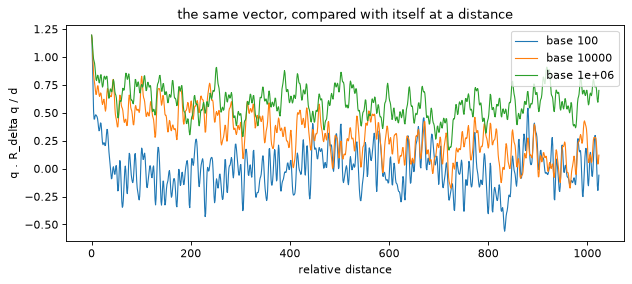

In [6]:
plt.figure(figsize=(9, 3.5))
distances = torch.arange(0, 1024)
x = torch.randn(head_dim)
for base in (100.0, 10_000.0, 1_000_000.0):
    c, s = rope_cache(1024, head_dim, base)
    rotated = apply_rope(x.expand(1, 1, 1024, head_dim), c, s)[0, 0]
    scores = rotated @ rotated[0] / head_dim  # position 0 against positions 0..1023
    plt.plot(distances, scores, label=f"base {base:g}", lw=1)
plt.xlabel("relative distance")
plt.ylabel("q . R_delta q / d")
plt.legend()
plt.title("the same vector, compared with itself at a distance")
plt.show()

base 小時高低頻都轉得快，分數在短距離內就劇烈震盪；base 大時低頻維度幾乎不轉，遠距離的分數保持得比較好。這是長 context 模型常把 base 調大的原因之一（nanochat 用 100,000）。

## 5. 零件比較

### 5.1 LayerNorm vs RMSNorm

In [7]:
from lm_course.model import RMSNorm

x = torch.randn(4, 256) * 3 + 5  # large mean and scale
ln = torch.nn.LayerNorm(256, elementwise_affine=False)(x)
rms = RMSNorm(256, affine=False)(x)
for name, y in [("input", x), ("LayerNorm", ln), ("RMSNorm", rms)]:
    print(f"{name:>9}: mean {y.mean(-1).mean():+.3f}, rms {y.pow(2).mean(-1).sqrt().mean():.3f}")

    input: mean +5.095, rms 5.902
LayerNorm: mean -0.000, rms 1.000
  RMSNorm: mean +0.863, rms 1.000


LayerNorm 讓每個向量平均 0、變異數 1；RMSNorm 只把均方根拉到 1，平均值保留。在 residual stream 裡平均值本來就接近 0，所以兩者差不多，RMSNorm 少算一步。

### 5.2 激活函數

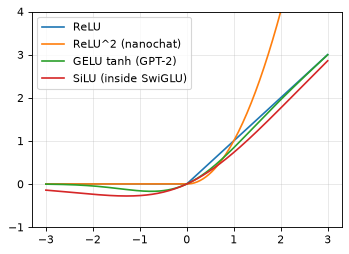

In [8]:
z = torch.linspace(-3, 3, 200)
plt.figure(figsize=(5, 3.5))
plt.plot(z, F.relu(z), label="ReLU")
plt.plot(z, F.relu(z) ** 2, label="ReLU^2 (nanochat)")
plt.plot(z, F.gelu(z, approximate="tanh"), label="GELU tanh (GPT-2)")
plt.plot(z, F.silu(z), label="SiLU (inside SwiGLU)")
plt.ylim(-1, 4)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5.3 參數量：$12d^2$ 與 GQA

In [9]:
from lm_course.model import Block, gpt2_config, llama_style_config

d = 768
blocks = {
    "GPT-2 (MHA, GELU 4d)": gpt2_config("gpt2"),
    "Llama-style (MHA, SwiGLU)": llama_style_config(d_model=d, n_head=12),
    "Llama-style GQA (4 kv heads)": llama_style_config(d_model=d, n_head=12, n_kv_head=4),
}
for name, cfg in blocks.items():
    with torch.device("meta"):
        block = Block(cfg)
    matrices = sum(p.numel() for p in block.parameters() if p.dim() == 2)
    print(f"{name:<30} matrices {matrices / 1e6:6.3f}M  = {matrices / d**2:5.2f} d^2")

GPT-2 (MHA, GELU 4d)           matrices  7.078M  = 12.00 d^2
Llama-style (MHA, SwiGLU)      matrices  7.078M  = 12.00 d^2
Llama-style GQA (4 kv heads)   matrices  6.291M  = 10.67 d^2


GPT-2 的區塊正好 $12d^2$（式 4.11）；SwiGLU 的 $d_{ff} = \tfrac{8}{3} \times 768 = 2048$，三個矩陣的參數和 GPT-2 的兩個 $4d$ 矩陣一樣多（講義式 4.10）；GQA 用 4 組 key／value 服務 12 個 query head，$W_K$、$W_V$ 各縮成 $1/3$，少了 $\tfrac{4}{3}d^2$。

## 小結

- attention ＝ 用 query–key 的吻合度對 value 做加權平均；causal mask 讓一次 forward 訓練所有位置。
- $\sqrt{d_k}$ 縮放讓 softmax 不飽和。
- attention 本身不知道順序；RoPE 用旋轉把「相對距離」放進分數裡。
- 下一課把這些零件組成 GPT-2，並載入 OpenAI 的權重。

下一步：[第 05 課](../lessons/05_gpt2.md)。